MCMC metropolis_line1

In [ ]:
!pip install corner


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import corner

In [ ]:
data = np.loadtxt("/content/line-1.dat")

x = data[0]
y = data[1]
yerr = data[2]
# definimos los modelos

def modelo_lineal(x, m, b):
  return m*x + b

def chi2_lineal(theta, x, y ,yerr):
  m, b = theta
  y_model = modelo_lineal(x, m, b)
  chi2= np.sum(((y-y_model)/yerr)**2)
  return chi2

def chi2_con_f(theta, x, y, yerr):
  m, b, log_f= theta
  f = np.exp(log(f))
  y_model = modelo_lineal(x, m, b)

  sigma2= yerr**2 + f**2 *y_model**2
  chi2= np.sum((y-y_model)**2/sigma2)
  return chi2





In [ ]:
def log_likelihood_lineal(theta, x, y, yerr):
    m, b = theta
    y_model = modelo_lineal(x, m, b)
    sigma2 = yerr**2
    return -0.5 * np.sum( (y - y_model)**2 / sigma2 + np.log(sigma2) )


def log_likelihood_con_f(theta, x, y, yerr):
    m, b, log_f = theta
    f = np.exp(log_f)
    y_model = modelo_lineal(x, m, b)
    sigma2= yerr**2 + f**2 *y_model**2
    return -0.5*np.sum((y - y_model)**2/sigma2 + np.log(sigma2))

In [ ]:

def log_prior_lineal(theta):
   m, b = theta
   if -5.0 < m < 0.5 and 0.0 < b < 10.0 :
        return 0.0
   return -np.inf



def log_prior_con_f(theta):
    m, b, log_f = theta
    if -5.0 < m < 0.5 and 0.0 < b < 10.0 and -10.0 < log_f < 1.0:
        return 0.0
    return -np.inf

In [ ]:
def log_prob_lineal(theta, x, y, yerr):
    lp = log_prior_lineal(theta)

    if not np.isfinite(lp):
        return -np.inf

    return lp + log_likelihood_lineal(theta, x, y, yerr)

def log_prob_con_f(theta, x, y, yerr):
    lp = log_prior_con_f(theta)

    if not np.isfinite(lp):
        return -np.inf

    return lp + log_likelihood_con_f(theta, x, y, yerr)

In [ ]:
def metropolis(log_prob, theta0, pasos, escala, x, y, yerr):
    ndim = len(theta0)

    cadena = np.zeros((pasos, ndim))
    aceptados = 0

    theta_actual = np.array(theta0)
    logp_actual = log_prob(theta_actual, x, y, yerr)

    for i in range(pasos):
        propuesta = theta_actual + escala*np.random.randn(ndim)

        logp_propuesta = log_prob(propuesta, x, y, yerr)

        log_alpha = logp_propuesta - logp_actual

        if np.log(np.random.rand()) < log_alpha:
            theta_actual = propuesta
            logp_actual = logp_propuesta
            aceptados += 1

        cadena[i] = theta_actual

    tasa = aceptados / pasos

    return cadena, tasa

In [ ]:
def varios_caminadores(log_prob, theta_centro, nwalkers, pasos, escala_inicio, escala_paso, x, y, yerr):
    cadenas = []
    tasas = []

    for i in range(nwalkers):
        theta0 = theta_centro + escala_inicio*np.random.randn(len(theta_centro))

        cadena, tasa = metropolis(
            log_prob,
            theta0,
            pasos,
            escala_paso,
            x,
            y,
            yerr
        )

        cadenas.append(cadena)
        tasas.append(tasa)

    return np.array(cadenas), np.array(tasas)

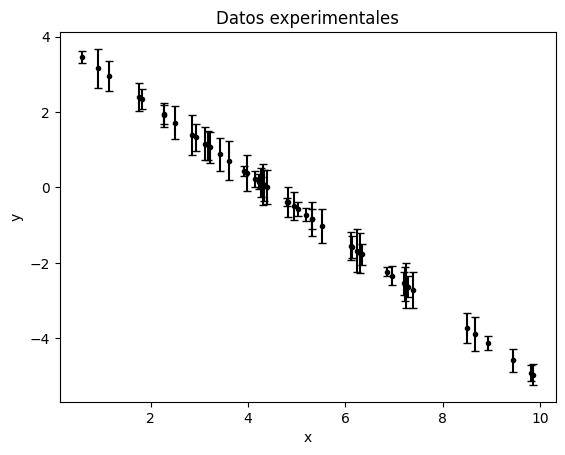

In [ ]:
plt.errorbar(x, y, yerr=yerr, fmt=".k", capsize=3)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Datos experimentales")
plt.show()

Estimación inicial:
m0 = -0.9100000000000001
b0 = 3.9999999999999996


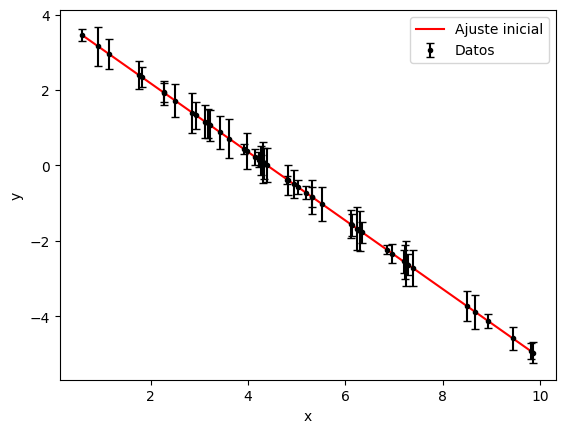

In [ ]:
#Estimacion inicial+
m0, b0 = np.polyfit(x, y, 1)

print("Estimación inicial:")
print("m0 =", m0)
print("b0 =", b0)

x0 = np.linspace(np.min(x), np.max(x), 500)

plt.errorbar(x, y, yerr=yerr, fmt=".k", capsize=3, label="Datos")
plt.plot(x0, m0*x0 + b0, "r", label="Ajuste inicial")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [ ]:
# MCMC lineal
cadenas_lin, tasas_lin = varios_caminadores(
    log_prob_lineal,
    theta_centro=np.array([m0, b0]),
    nwalkers=20,
    pasos=10000,
    escala_inicio=np.array([0.05, 0.3]),
    escala_paso=np.array([0.005, 0.03]),
    x=x,
    y=y,
    yerr=yerr
)

print("Tasa media de aceptación lineal:", np.mean(tasas_lin))

Tasa media de aceptación lineal: 0.661735


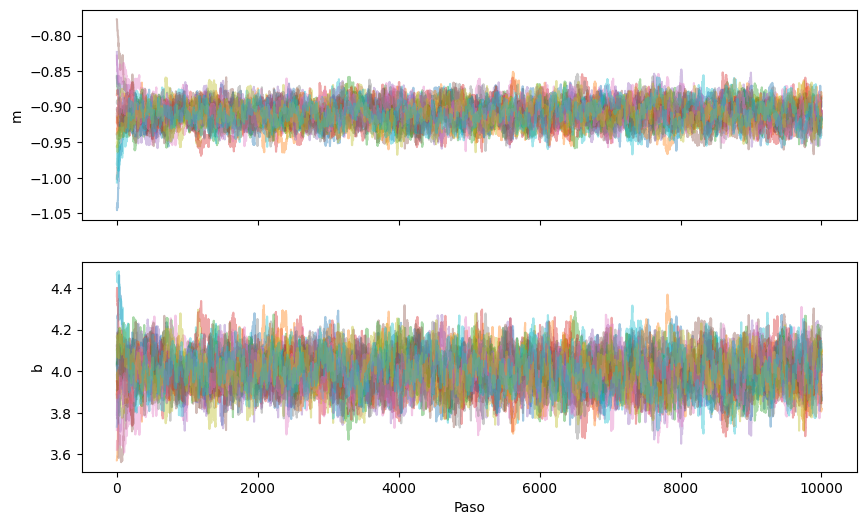

In [ ]:
labels_lin = ["m", "b"]

fig, axes = plt.subplots(2, figsize=(10, 6), sharex=True)

for j in range(2):
    for i in range(cadenas_lin.shape[0]):
        axes[j].plot(cadenas_lin[i, :, j], alpha=0.4)

    axes[j].set_ylabel(labels_lin[j])

axes[-1].set_xlabel("Paso")
plt.show()

In [ ]:
burnin = 2000

samples_lin = cadenas_lin[:, burnin:, :].reshape(-1, 2)

for i, label in enumerate(labels_lin):
    q16, q50, q84 = np.percentile(samples_lin[:, i], [16, 50, 84])
    print(f"{label} = {q50:.5f} -{q50-q16:.5f} +{q84-q50:.5f}")

m = -0.90965 -0.01622 +0.01654
b = 3.99780 -0.09224 +0.09025


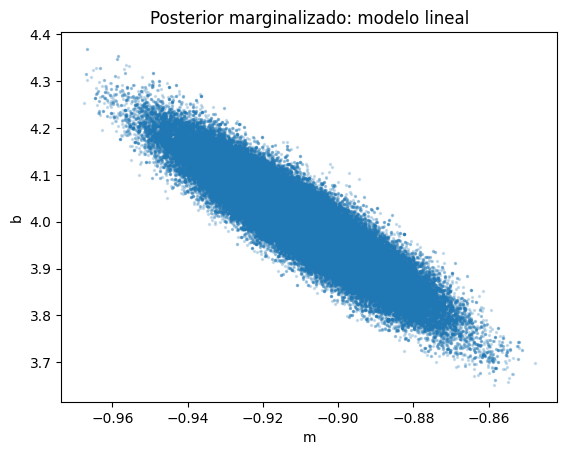

In [ ]:
plt.scatter(samples_lin[:,0], samples_lin[:,1], s=2, alpha=0.2)
plt.xlabel("m")
plt.ylabel("b")
plt.title("Posterior marginalizado: modelo lineal")
plt.show()

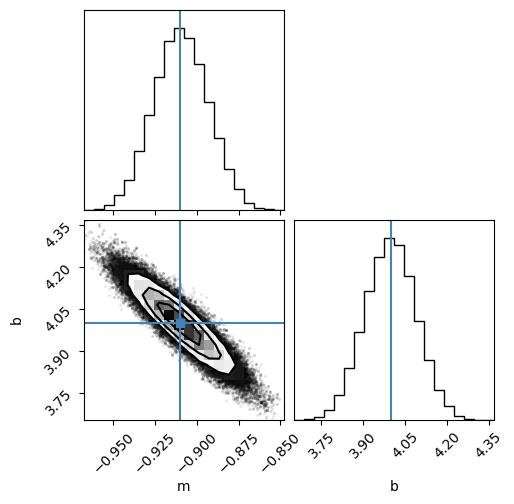

In [ ]:
corner.corner(samples_lin, labels=['m','b'], truths=[m0,b0])
plt.show()


In [ ]:
# MCMC con f
cadenas_f, tasas_f= varios_caminadores(log_prob_con_f,
                                      theta_centro=np.array([m0, b0, np.log(0.1)]),
                                      nwalkers=20, pasos=10000,
                                      escala_inicio=np.array([0.05, 0.3,0.5]),
                                      escala_paso=np.array([0.005, 0.03,0.08]),
                                      x=x, y=y, yerr=yerr)

print("Tasa media de aceptación con f:", np.mean(tasas_f))

Tasa media de aceptación con f: 0.6610750000000001


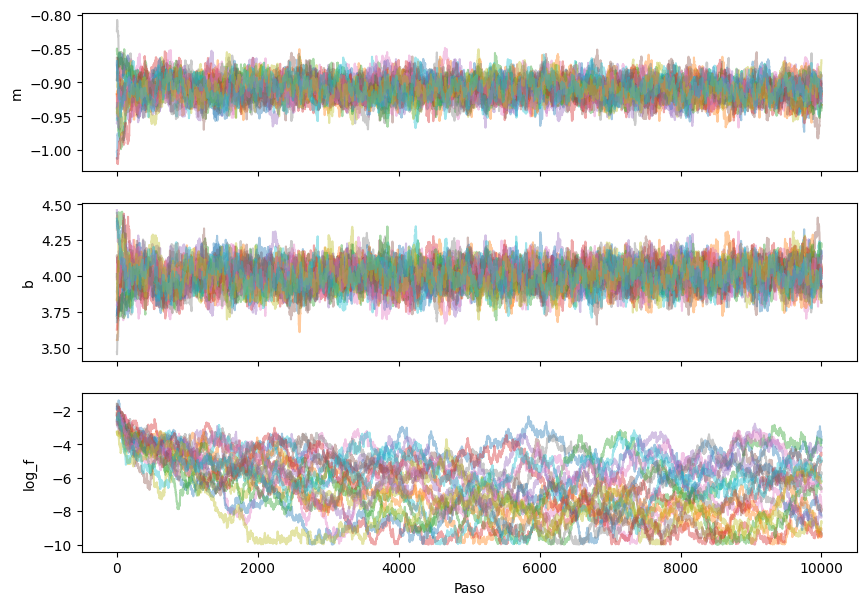

In [ ]:
labels_f = ["m", "b", 'log_f']

fig, axes = plt.subplots(3, figsize=(10, 7), sharex=True)

for j in range(3):
    for i in range(cadenas_f.shape[0]):
        axes[j].plot(cadenas_f[i, :, j], alpha=0.4)

    axes[j].set_ylabel(labels_f[j])

axes[-1].set_xlabel("Paso")
plt.show()

In [ ]:
burnin = 2000

samples_f = cadenas_f[:, burnin:, :].reshape(-1, 3)

for i, label in enumerate(labels_f):
    q16, q50, q84 = np.percentile(samples_f[:, i], [16, 50, 84])
    print(f"{label} = {q50:.5f} -{q50-q16:.5f} +{q84-q50:.5f}")
f_samples = np.exp(samples_f[:,2])
q16, q50, q84 = np.percentile(f_samples, [16, 50, 84])

print(f"f = {q50:.5f} -{q50-q16:.5f} +{q84-q50:.5f}")

m = -0.91014 -0.01597 +0.01548
b = 4.00051 -0.08686 +0.08953
log_f = -6.70958 -1.87598 +1.78511
f = 0.00122 -0.00103 +0.00605


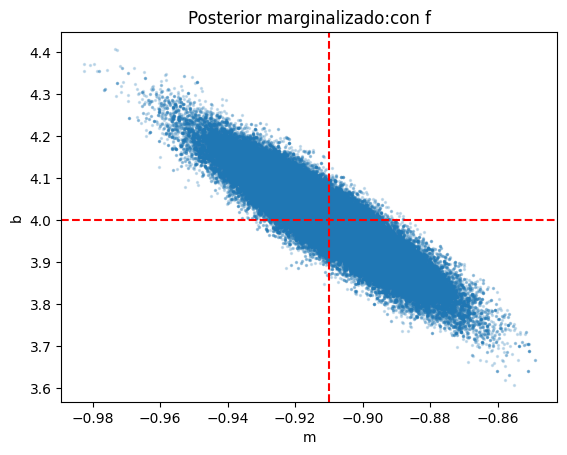

In [ ]:
plt.scatter(samples_f[:,0], samples_f[:,1], s=2, alpha=0.2)
plt.axvline(-0.91, color="red", linestyle="--")
plt.axhline(4.0, color="red", linestyle="--")
plt.xlabel("m")
plt.ylabel("b")
plt.title("Posterior marginalizado:con f")
plt.show()

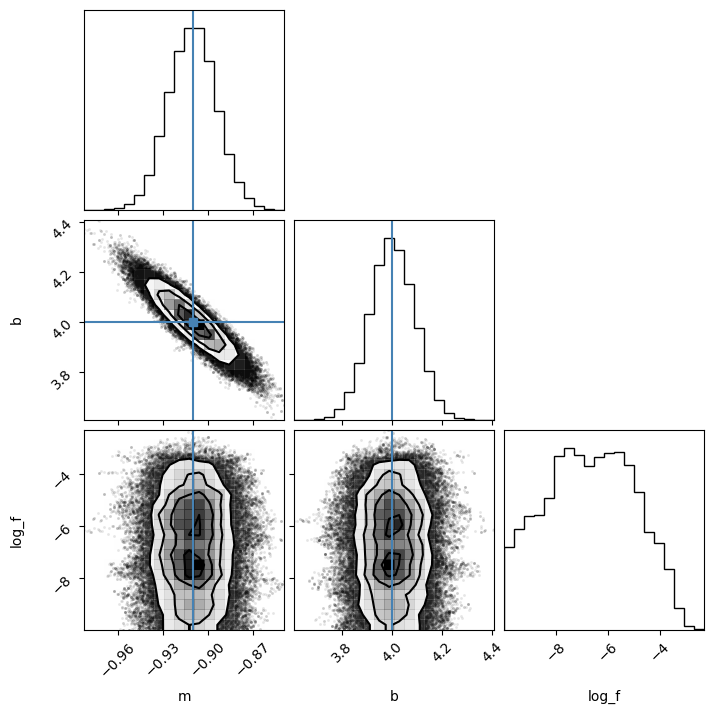

In [ ]:
corner.corner(samples_f, labels=['m','b','log_f'], truths=[m0,b0, None])
plt.show()

Comparacion

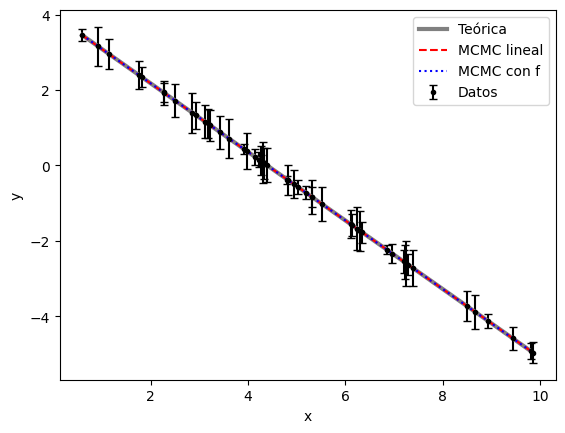

In [ ]:
m_lin=np.percentile(samples_lin[:,0],50)
b_lin=np.percentile(samples_lin[:,1],50)

m_f=np.percentile(samples_f[:,0],50)
b_f=np.percentile(samples_f[:,1],50)

m_teo=-0.91
b_teo= 4.0

plt.errorbar(x, y, yerr=yerr, fmt=".k", capsize=3, label="Datos")

plt.plot(x0, m_teo*x0 + b_teo, "gray", lw=3, label="Teórica")
plt.plot(x0, m_lin*x0 + b_lin, "r--", label="MCMC lineal")
plt.plot(x0, m_f*x0 + b_f, "b:", label="MCMC con f")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()